# 02 — SAC Training

This notebook trains a **Soft Actor-Critic (SAC)** agent on `HvacEnv`.

### Algorithm recap (Eq. 7)
SAC maximises the entropy-regularised objective:

$$J(\pi) = \sum_t \mathbb{E}_{(s_t, a_t) \sim \rho_\pi} \left[ r(s_t, a_t) + \alpha \mathcal{H}(\pi(\cdot \mid s_t)) \right]$$

where $\alpha$ is the temperature parameter balancing reward maximisation and entropy (automatic tuning enabled).

### Training config
- **Policy**: MlpPolicy [64, 64]
- **Timesteps**: 300 000
- **Parallel envs**: 4
- **Buffer size**: 200 000
- **Batch size**: 256
- **γ**: 0.99


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from smart_hvac.core.parameters import Parameters
from smart_hvac.envs.hvac_env import HvacEnv
from smart_hvac.rl.train_sac import train_sac
from smart_hvac.rl.policies import LoadedPolicy
from smart_hvac.control.thermostat import Thermostat
from smart_hvac.control.pid_controller import PIDController
from smart_hvac.evaluation.rollouts import run_rollout, run_rollouts
from smart_hvac.evaluation.metrics import compute_metrics, aggregate_metrics
from smart_hvac.evaluation.plots import plot_training_curve

import os
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/logs',   exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

params = Parameters()
print('Ready. Starting SAC training...')

I0000 00:00:1779696942.193845 1307805 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779696942.622228 1307805 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779696944.364811 1307805 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779696944.367387 1307805 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

Ready. Starting SAC training...


## 2.1 Train SAC

Training takes ~5–15 min on CPU depending on your machine.  
Progress is printed every 10 000 steps. The model is saved to `results/models/sac_hvac.zip`.

In [2]:
model = train_sac(
    total_timesteps=300_000,
    seed=0,
    n_envs=4,
    learning_rate=3e-4,
    buffer_size=200_000,
    batch_size=256,
    gamma=0.99,
    net_arch=[64, 64],
    model_save_path='../results/models/sac_hvac',
    log_path='../results/logs/sac_eval.csv',
    eval_freq=10_000,
    verbose=1,
)
print('Training complete!')

Using cuda device
[SAC] Training for 300,000 timesteps on 4 parallel envs …
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 96        |
|    ep_rew_mean     | -1.32e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 384       |
|    time_elapsed    | 0         |
|    total_timesteps | 384       |
| train/             |           |
|    actor_loss      | 0.723     |
|    critic_loss     | 3.33e+04  |
|    ent_coef        | 0.98      |
|    ent_coef_loss   | -0.035    |
|    learning_rate   | 0.0003    |
|    n_updates       | 70        |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 96        |
|    ep_rew_mean     | -9.15e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 466       |
|    time_elapsed    | 1         |
|    total_timesteps | 768       |
| train/      

## 2.2 Training curve

 timestep  mean_reward  std_reward  mean_comfort_dev  pct_in_band  total_energy_kwh
    40000    -4.096756    0.138681          1.642028     5.000000         33.769221
    80000    -8.890550    0.129758          2.212130    31.250000         32.041576
   120000    -7.772596    0.103412          2.103363    20.000000         31.707842
   160000    -4.331857    0.215726          1.331086    44.791667         36.354582
   200000    -2.694957    0.159516          1.000534    47.916667         38.402059
   240000    -1.995304    0.117437          0.918861    31.875000         37.566157
   280000    -2.125189    0.174971          0.915458    40.416667         38.163360


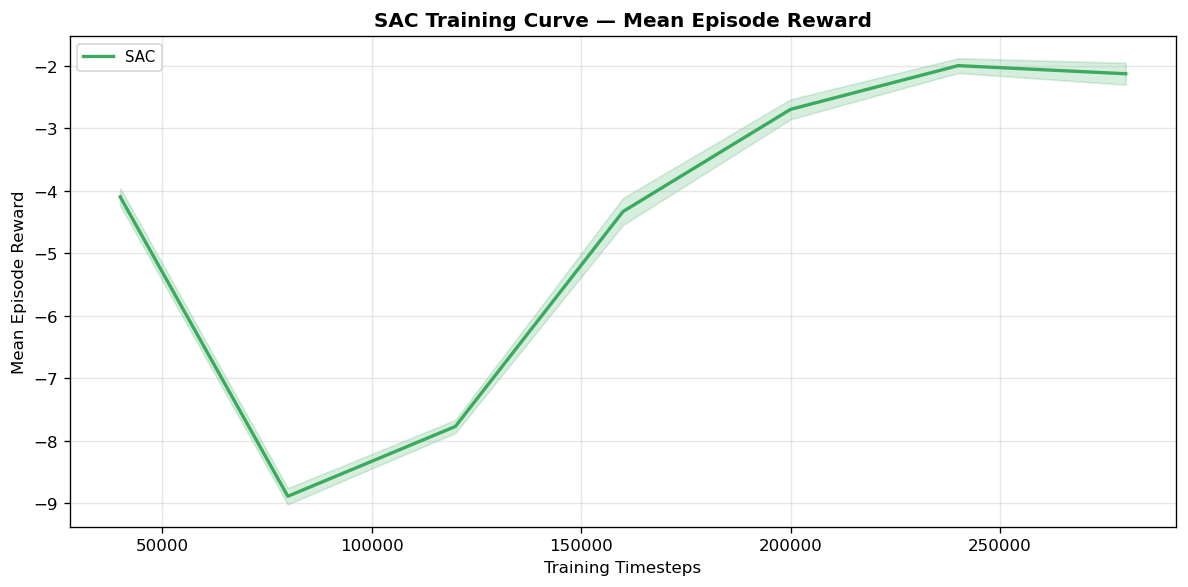

In [3]:
log = pd.read_csv('../results/logs/sac_eval.csv')
print(log.tail(10).to_string(index=False))

fig = plot_training_curve(
    timesteps=log['timestep'].values,
    mean_rewards=log['mean_reward'].values,
    std_rewards=log['std_reward'].values,
    label='SAC',
    title='SAC Training Curve — Mean Episode Reward'
)
fig.savefig('../results/figures/02_sac_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Comfort and energy metrics over training

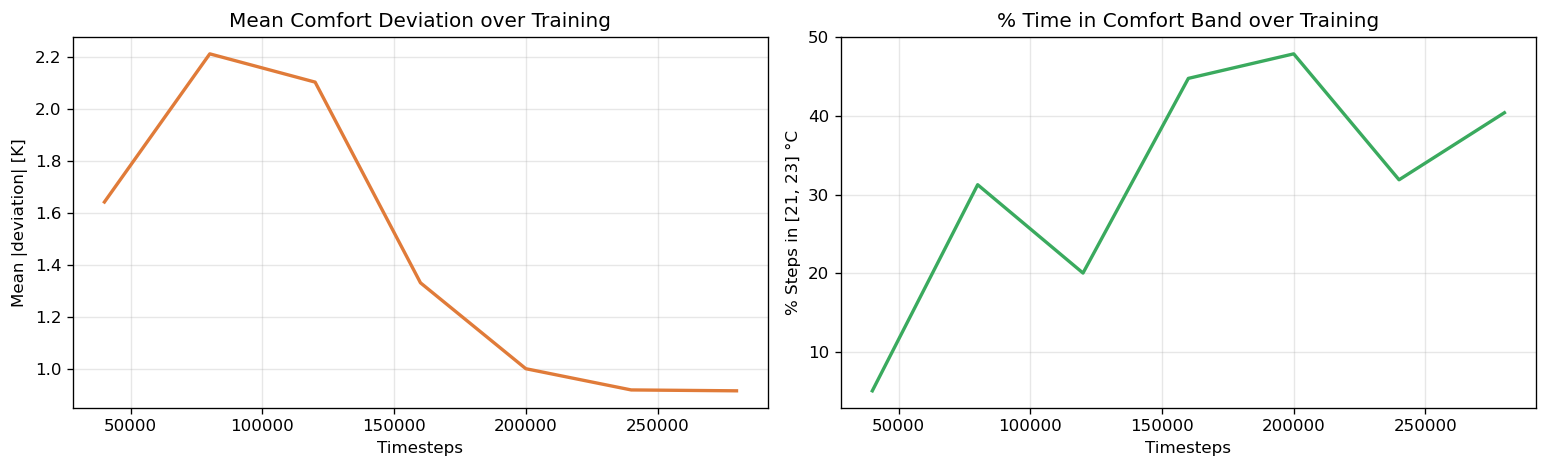

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(log['timestep'], log['mean_comfort_dev'], color='#e07b39', linewidth=2)
axes[0].set_title('Mean Comfort Deviation over Training')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Mean |deviation| [K]')
axes[0].grid(True, alpha=0.3)

axes[1].plot(log['timestep'], log['pct_in_band'], color='#3aaa5e', linewidth=2)
axes[1].set_title('% Time in Comfort Band over Training')
axes[1].set_xlabel('Timesteps')
axes[1].set_ylabel('% Steps in [21, 23] °C')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('../results/figures/02_sac_comfort_energy.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Quick evaluation of trained SAC vs baselines

In [5]:
sac_policy = LoadedPolicy('../results/models/sac_hvac', algo='sac')

eval_policies = {
    'Thermostat': (Thermostat(params=params), True),
    'PID':        (PIDController(params=params), True),
    'SAC':        (sac_policy, False),
}

summary = {}
for name, (policy, is_bl) in eval_policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=0)
    trajs = run_rollouts(policy, env, n_episodes=10, base_seed=100, is_baseline=is_bl)
    agg = aggregate_metrics(trajs)
    summary[name] = {
        'mean_comfort_dev':  agg['mean_comfort_dev']['mean'],
        'pct_in_band':       agg['pct_in_band']['mean'],
        'total_energy_kwh':  agg['total_energy_kwh']['mean'],
        'mean_reward':       agg['mean_reward']['mean'],
    }

print('\n=== Quick Eval — 10 cold-day episodes ===')
df = pd.DataFrame(summary).T
print(df.round(4).to_string())


=== Quick Eval — 10 cold-day episodes ===
            mean_comfort_dev  pct_in_band  total_energy_kwh  mean_reward
Thermostat            3.5035      24.1667           71.0250     -21.2861
PID                   3.5001      20.6250           69.9265     -21.0382
SAC                   3.8405      18.8542           68.5348     -24.4181


## 2.5 Sample trajectory — SAC on cold day

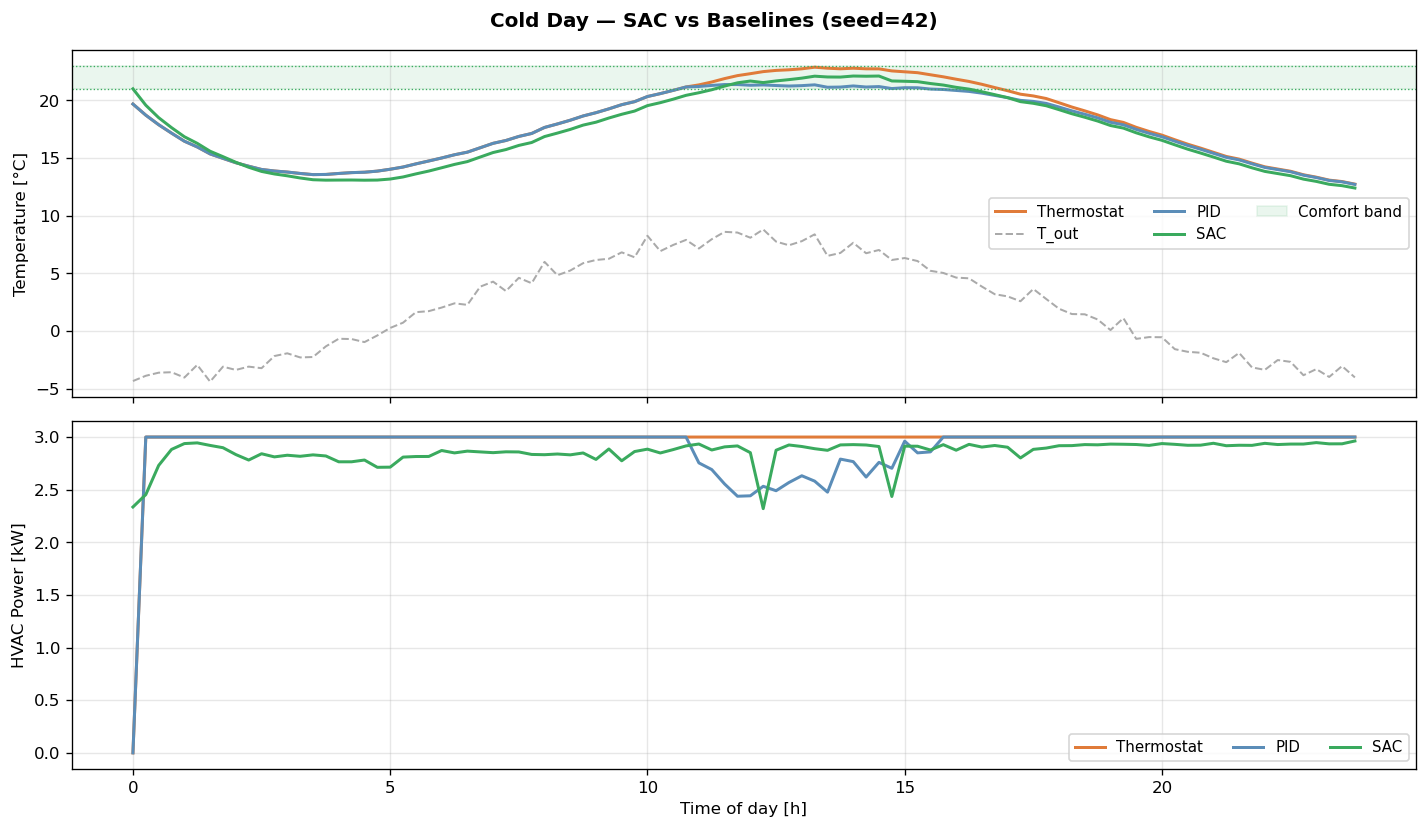

In [6]:
from smart_hvac.evaluation.plots import plot_timeseries

sample_trajs = {}
for name, (policy, is_bl) in eval_policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=42)
    traj = run_rollout(policy, env, seed=42, is_baseline=is_bl)
    sample_trajs[name] = traj

fig = plot_timeseries(
    sample_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='Cold Day — SAC vs Baselines (seed=42)'
)
fig.savefig('../results/figures/02_sac_vs_baselines_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()